# FairFace Inference Demo

## Imports

In [ ]:
import torch
import matplotlib.pyplot as plt

import os
import csv

from PIL import Image

from multitask_vit import MultiTaskViT

from training.age_strategy import get_age_strategy
from training.checkpoint_utils import build_model_from_checkpoint

from model.siglip import model as siglip_model, processor as siglip_processor
from model.clip   import model as clip_model,   processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor

## Class Labels

In [2]:
gender_class = ["Male", "Female"]

age_class = ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49",
              "50-59", "60-69", "more than 70"]

race_class = ["East Asian", "Indian", "Black", "White", "Middle Eastern",
               "Latino_Hispanic", "Southeast Asian"]

## Utility Functions

### Checkpoint Loading

In [3]:
def load_checkpoint(raw_backbone, model_name, run_version, device):
    """
    Loads a trained model from its best-heads checkpoint. Self-configures
    age_loss_type and adapter method (LoRA/DoRA/none) from the checkpoint —
    works for both old head-only checkpoints and new adapter ones.
    """
    checkpoint = torch.load(
        f"../checkpoints/{model_name}/{run_version}/{model_name}-best-heads.pt",
        map_location=device
    )
    model, age_loss_type, adapter_cfg = build_model_from_checkpoint(checkpoint, raw_backbone, device=device)
    return model, age_loss_type, adapter_cfg


### Core Inference

The model outputs logits, which are converted into probabilities:

- Sigmoid is used for binary gender classification.
- Softmax is used for multi-class age and race classification.

The class with the highest probability is selected as the final prediction.

In [4]:
def get_logits(model, processor, image, device):
    """
    Run inference on a single image and extract raw logits.

    Returns:
        Dictionary containing raw logits for each task.
    """
    # print(processor.to_dict())

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values)

    # LOGITS
    return {
        'gender': outputs["gender"],
        'age': outputs["age"],
        'race': outputs["race"]
    }

In [5]:
def get_prediction_results(logits, age_loss_type="ce"):
    """
    Convert model logits into human-readable predictions.

    Applies:
    - Sigmoid for binary gender classification.
    - Softmax for age and race multi-class classification.

    The class with the highest probability is selected as prediction.

    Args:
        logits: Dictionary containing model outputs.

    Returns:
        Dictionary containing predicted classes and confidence scores.
    """
    strategy = get_age_strategy(age_loss_type)

    gender_prob = torch.sigmoid(logits['gender']).item()
    gender_idx = int(gender_prob > 0.5)
    gender_probs = [1 - gender_prob, gender_prob]

    age_idx = strategy.decode(logits['age']).item()
    age_probs_t, sortable = strategy.probs(logits['age'])
    age_probs = age_probs_t[0].cpu().tolist()
    age_prob = age_probs[age_idx] if sortable else None

    race_tensor = torch.softmax(logits['race'], dim=1)[0].cpu()
    race_idx = race_tensor.argmax().item()
    race_probs = race_tensor.tolist()

    return {
        'gender': gender_class[gender_idx], 
        'gender_prob': gender_probs[gender_idx],
        
        'age':    age_class[age_idx],       
        'age_prob':    age_prob,

        'race':   race_class[race_idx],     
        'race_prob':   race_probs[race_idx],
    }

def print_ranked(category, class_names, probabilities, sort=True):
    """
    Display class probabilities.

    Used for visualizing single image predictions.

    Args:
        category: Prediction category name.
        class_names: List of class labels.
        probabilities: Probability for each class.
        sort: If True, sort descending and report the argmax as the prediction
              (correct for softmax outputs — gender, race, CE age).
              If False, print in the given order without implying that the
              highest value is the prediction (needed for CORN's threshold
              pass-probabilities, which are monotonically decreasing and
              whose "highest" entry is almost always the first threshold,
              not the actual predicted class).

    Returns:
        The class with the highest probability if sort=True, otherwise None.
    """
    print(f"\n{category}:")

    pairs = list(zip(class_names, probabilities))

    if sort:
        pairs.sort(key=lambda pair: pair[1], reverse=True)

    for name, prob in pairs:
        percentage = prob * 100
        print(f"  {name:<20}: {percentage:.2f}%")

    if sort:
        top_name = pairs[0][0]
        print(f"  -> Prediction: {top_name}")
        return top_name

    return None

### Visualization Utilities

In [16]:
def display_compact_prediction(logits, age_loss_type="ce", face_idx=None):
    """Display only the final predictions for a single face."""
    strategy = get_age_strategy(age_loss_type)

    gender_prob = torch.sigmoid(logits["gender"]).item()
    gender_pred = gender_class[int(gender_prob >= 0.5)]

    age_idx = strategy.decode(logits["age"]).item()
    age_pred = age_class[age_idx]

    race_probs = torch.softmax(logits["race"], dim=1)
    race_pred = race_class[race_probs.argmax(dim=1).item()]

    if face_idx is not None:
        print(f"Face {face_idx}")
    print(f"  Gender: {gender_pred}")
    print(f"  Race: {race_pred}")
    print(f"  Age: {age_pred}")
    print()

In [6]:

def display_prediction(logits, name=None, age_loss_type="ce"):
    """
    Display prediction results for a single image.

    Shows probability ranking for:
    - Gender
    - Age
    - Race

    NOT used for CSV generation.

    Args:
        logits: Raw model outputs.
        name: Model name for display.
        age_loss_type: "ce" or "corn" — determines how age logits are decoded/displayed.
    """
    strategy = get_age_strategy(age_loss_type)
    model_name = "" if name is None else name

    gender_prob = torch.sigmoid(logits['gender']).item()
    gender_probs = [1 - gender_prob, gender_prob]

    age_idx = strategy.decode(logits['age']).item()
    age_probs_t, sortable = strategy.probs(logits['age'])
    age_probs = age_probs_t[0].cpu().tolist()

    race_probs = torch.softmax(logits['race'], dim=1)[0].cpu().tolist()

    print(f"{'-'*5}{model_name} Prediction Result{'-'*5}")

    predictions = {
        "Gender": print_ranked("Gender", gender_class, gender_probs),
        "Race":   print_ranked("Race", race_class, race_probs),
    }

    if sortable:
        predictions["Age"] = print_ranked("Age", age_class, age_probs)
    else:
        print_ranked("Age (threshold pass-probs)", [f"> {c}" for c in age_class[:-1]], age_probs, sort=False)
        predicted_age = age_class[age_idx]
        print(f"  -> Predicted age bin: {predicted_age}")
        predictions["Age"] = predicted_age

    print("\n\n")
    return predictions

In [7]:
def predict_image(model, processor, image_path, device, age_loss_type="ce"):
    image = Image.open(image_path).convert("RGB")
    logits = get_logits(model, processor, image, device)
    return get_prediction_results(logits, age_loss_type=age_loss_type)


def predict_folder(models_dict, folder_path, device, output_csv,
                    extensions=(".jpg", ".jpeg", ".png","webp")):
    """
    models_dict: {
        "name": (model, processor, age_loss_type)
    }
    """
    image_files = sorted(
        f for f in os.listdir(folder_path)
        if f.lower().endswith(extensions)
    )

    fieldnames = ["image", "model", "gender", "gender_prob",
                  "age", "age_prob", "race", "race_prob"]

    with open(output_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for image_file in image_files:
            image_path = os.path.join(folder_path, image_file)

            for model_name, (model, processor, age_loss_type) in models_dict.items():
                result = predict_image(model, processor, image_path, device, age_loss_type=age_loss_type)
                writer.writerow({
                    "image": image_file,
                    "model": model_name,
                    **result,
                    
                })

    print(f"Saved predictions to {output_csv}")

## Load The Models

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_v2_model, clip_v2_age_type, _ = load_checkpoint(
    clip_model, "clip", "v2", device
)

clip_v3_model, clip_v3_age_type, clip_v3_adapter_cfg = load_checkpoint(
    clip_model, "clip", "v3", device
)


siglip_v2_model, siglip_v2_age_type, _  = load_checkpoint(
    siglip_model, "siglip", "v2", device
)

siglip_v3_model, siglip_v3_age_type, _  = load_checkpoint(
    siglip_model, "siglip", "v3", device
)


dinov2_v2_model, dinov2_v2_age_type, _  = load_checkpoint(
    dinov2_model, "dinov2", "v2", device
)

dinov2_v3_model, dinov2_v3_age_type, _  = load_checkpoint(
    dinov2_model, "dinov2", "v3", device
)




# fairface_clip_corn_model = load_checkpoint(FairFaceViT(clip_model, age_loss_type="corn"), "clip", "v3-corn", device)

# fairface_clipv2_1_model = load_checkpoint(
#     FairFaceViT(clip_model),
#     "clip",
#     "v2-1",
#     device
# )

In [9]:
print(clip_v3_adapter_cfg)

AdapterConfig(method='lora', r=8, alpha=16, dropout=0.05, target_modules=['q_proj', 'v_proj'])


In [10]:
models_dict = {
    "clip-v3":          (clip_v3_model, clip_processor,   clip_v3_age_type),
    "dinov2-v3":        (dinov2_v3_model,  dinov2_processor, dinov2_v3_age_type),
    "siglip-v3":        (siglip_v3_model,  siglip_processor, siglip_v3_age_type),
}

In [11]:
# print(fairface_clip_model)

## Folder Inference

In [12]:
predict_folder(models_dict, "../test-images/", device, "predictions.csv")

Saved predictions to predictions.csv


## Single Image Inference

### Face detector

In [13]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np

FACE_DETECTOR_MODEL_PATH = "model/blaze_face_full_range.tflite"

_base_options = python.BaseOptions(model_asset_path=FACE_DETECTOR_MODEL_PATH)
_detector_options = vision.FaceDetectorOptions(
    base_options=_base_options,
    min_detection_confidence=0.3
)
face_detector = vision.FaceDetector.create_from_options(_detector_options)


def detect_faces(image: Image.Image, padding_ratio=0.25):
    """
    Detect faces in a PIL image and return cropped face images with padding.

    Args:
        image: PIL Image (RGB).
        padding_ratio: fraction of face box size to pad on each side.

    Returns:
        List of dicts: {"crop": PIL.Image, "bbox": (x, y, w, h)}
    """
    np_image = np.array(image.convert("RGB"))
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np_image)

    result = face_detector.detect(mp_image)

    img_w, img_h = image.size
    faces = []

    for detection in result.detections:
        bbox = detection.bounding_box
        x, y, w, h = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height

        pad_x = int(w * padding_ratio)
        pad_y = int(h * padding_ratio)

        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(img_w, x + w + pad_x)
        y2 = min(img_h, y + h + pad_y)

        crop = image.crop((x1, y1, x2, y2))
        faces.append({
            "crop": crop,
            "bbox": (x, y, w, h),          
            "padded_bbox": (x1, y1, x2 - x1, y2 - y1)
        })

    return faces

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788640074.366151   44240 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Image selection

In [14]:
image = Image.open("../test-images/test.jpeg").convert("RGB")
faces = detect_faces(image, padding_ratio=0.1)
print(f"Detected {len(faces)} face(s)")

Detected 3 face(s)


### Inference Results

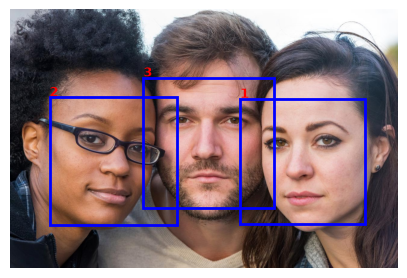

Face 1
  Gender: Female
  Race: White
  Age: 20-29

Face 2
  Gender: Female
  Race: Black
  Age: 20-29

Face 3
  Gender: Male
  Race: White
  Age: 30-39



In [18]:
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image)

for i, face in enumerate(faces):
    x, y, w, h = face["padded_bbox"]
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor='blue', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x, y - 5, f"{i+1}", color='red', fontsize=9, weight='bold')

ax.axis('off')
plt.show()


for i, face in enumerate(faces):
    crop = face["crop"]
    clip_v3_logits = get_logits(clip_v3_model, clip_processor, crop, device)
    display_compact_prediction(clip_v3_logits, age_loss_type=clip_v3_age_type, face_idx=i+1)
    # display_prediction(clip_v3_logits, f'CLIP v3 - Face {i+1}', age_loss_type=clip_v3_age_type)